In [12]:
import os
import json
import base64
from pathlib import Path
from typing import List
from dotenv import load_dotenv
from openai import OpenAI

[{'type': 'text', 'text': 'i will provide you a picture and you need to write a overall purpose of the page'}, {'type': 'image_url', 'image_url': {'url': ''}}]
[{'type': 'text', 'text': 'i will provide you a picture and you need to write a overall purpose of the page'}, {'type': 'image_url', 'image_url': {'url': ''}}, {'type': 'image_url', 'image_url': {'url': ''}}]
[{'type': 'text', 'text': 'i will provide you a picture and you need to write a overall purpose of the page'}, {'type': 'image_url', 'image_url': {'url': ''}}, {'type': 'image_url', 'image_url': {'url': ''}}, {'type': 'image_url', 'image_url': {'url': ''}}]

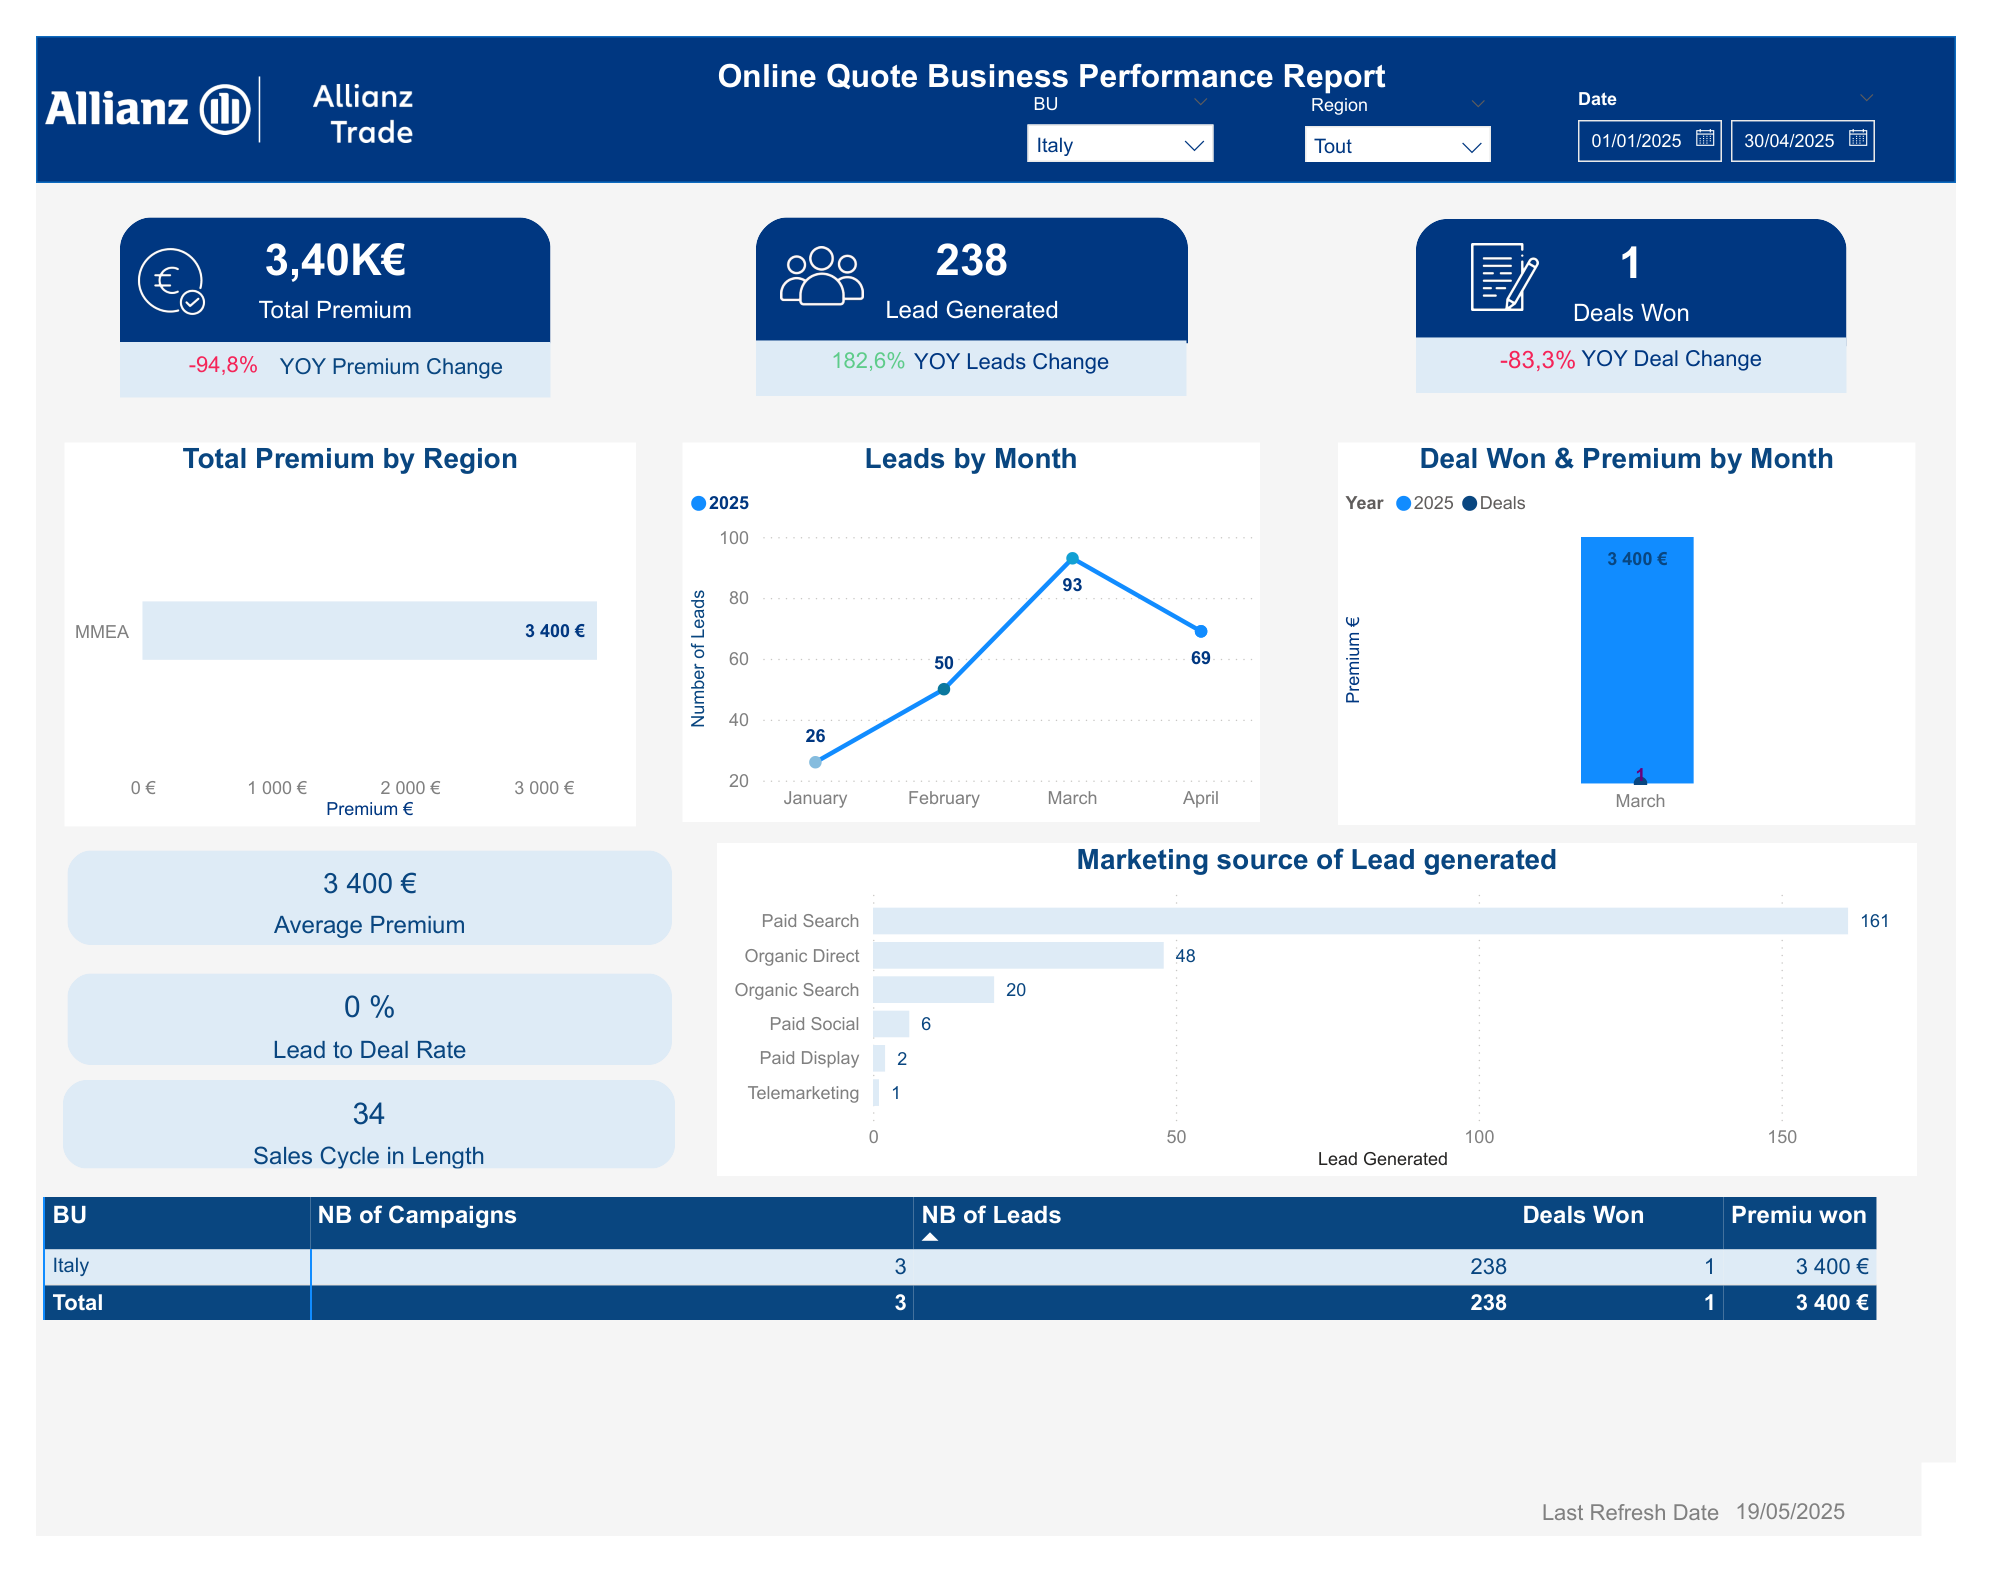
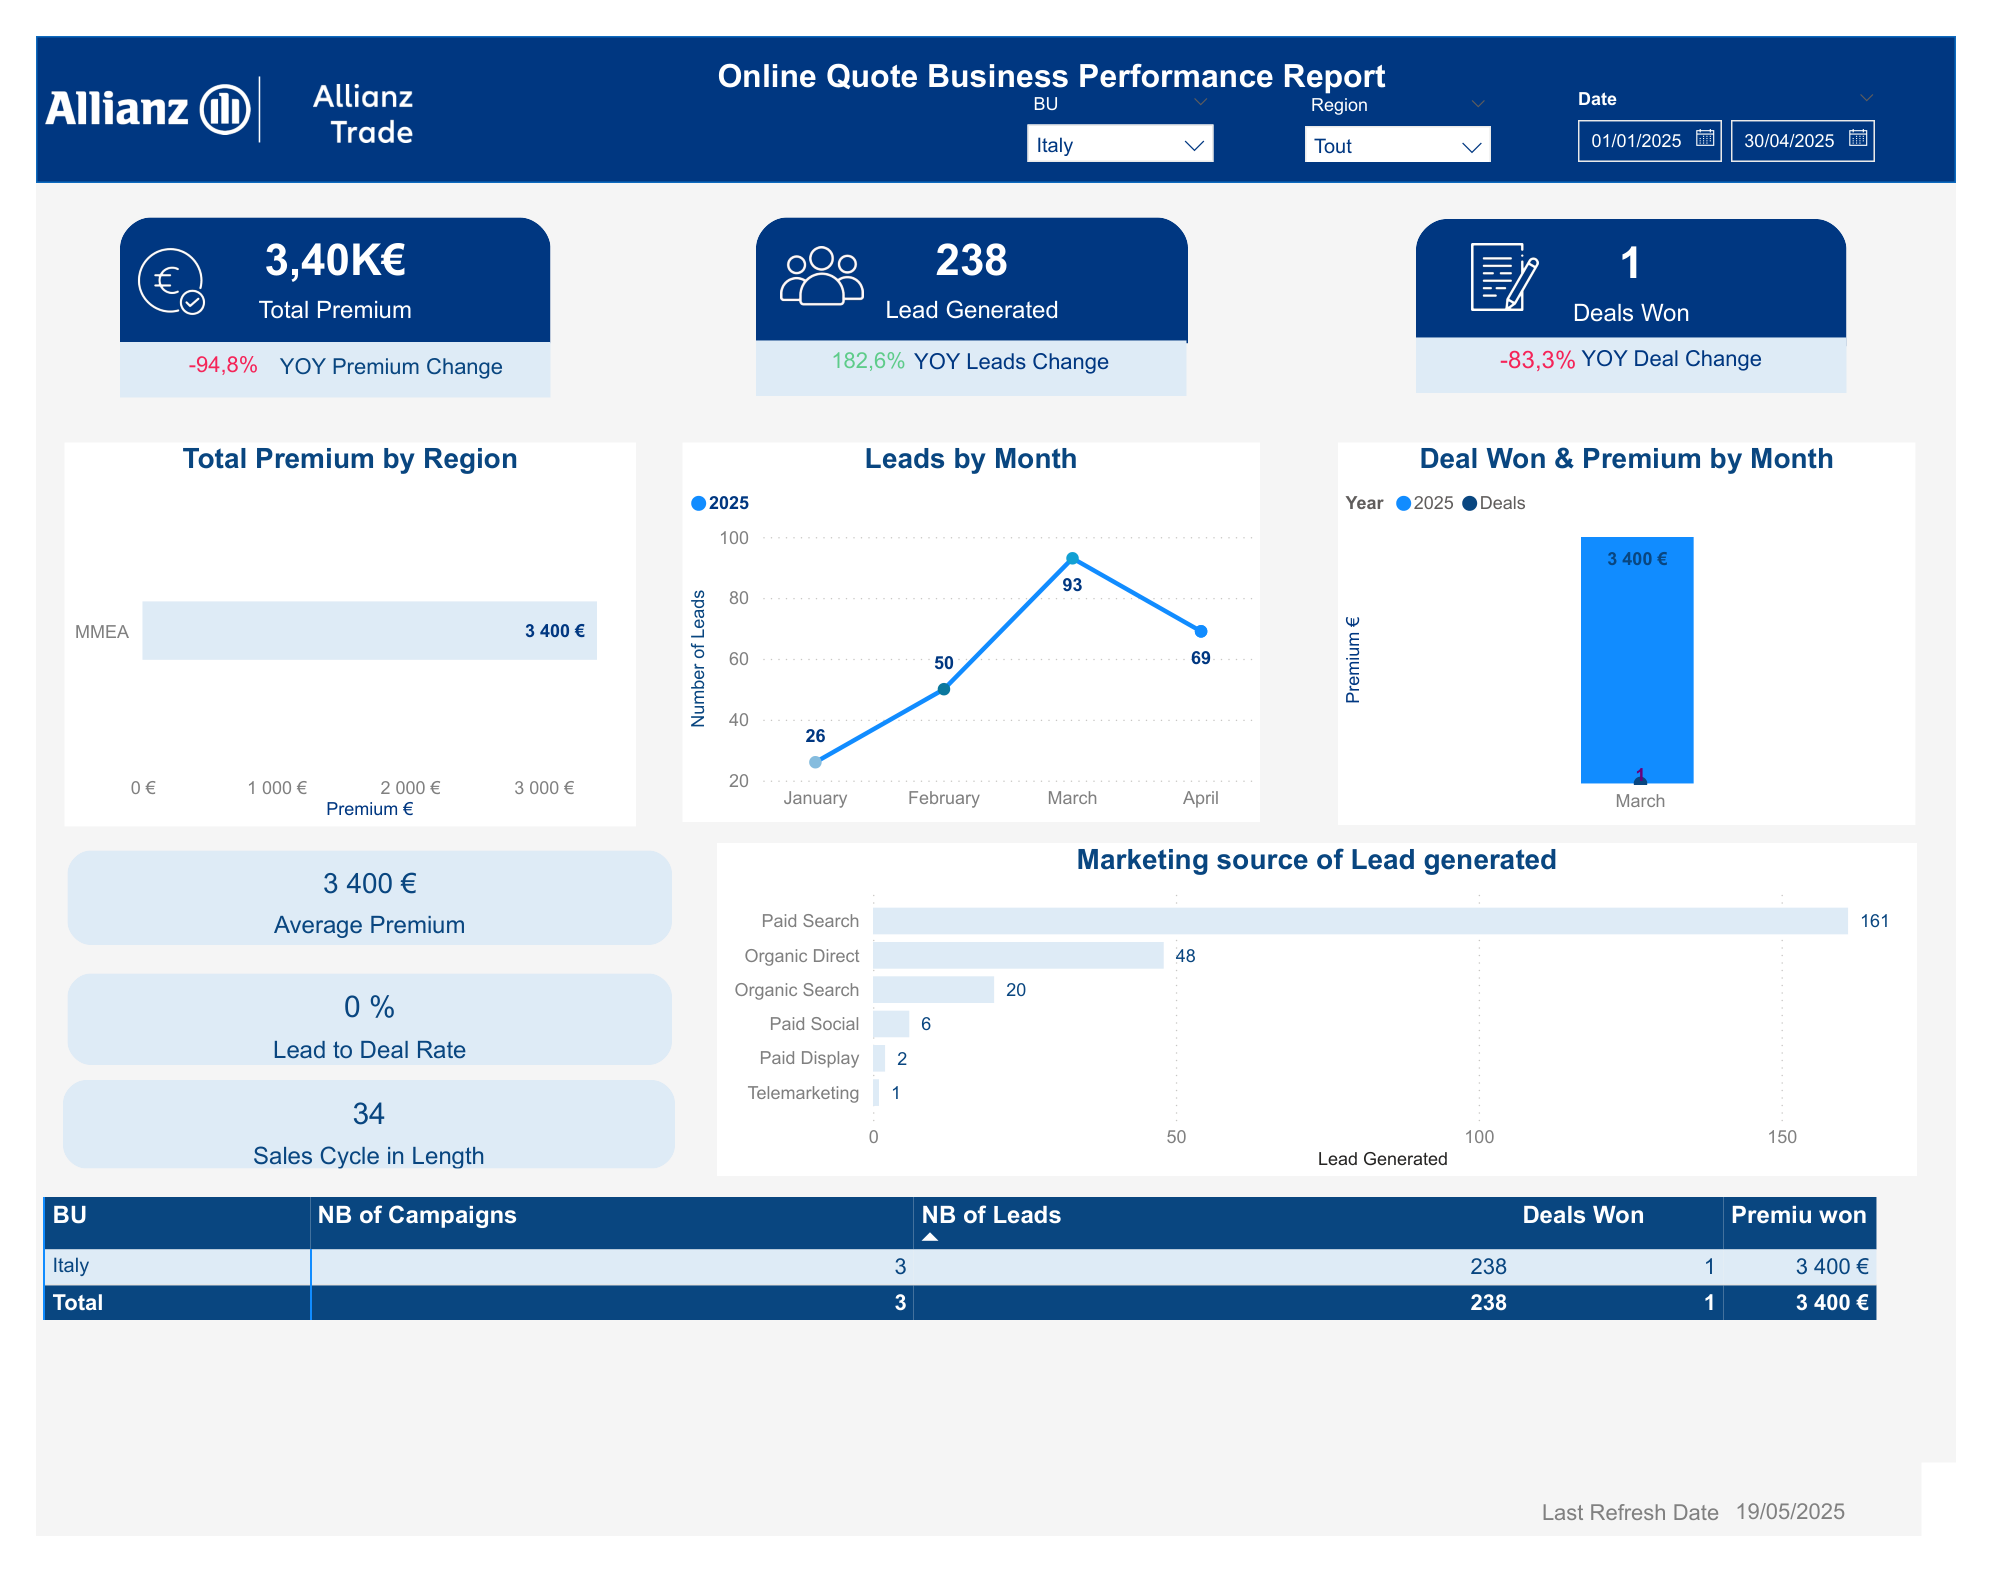
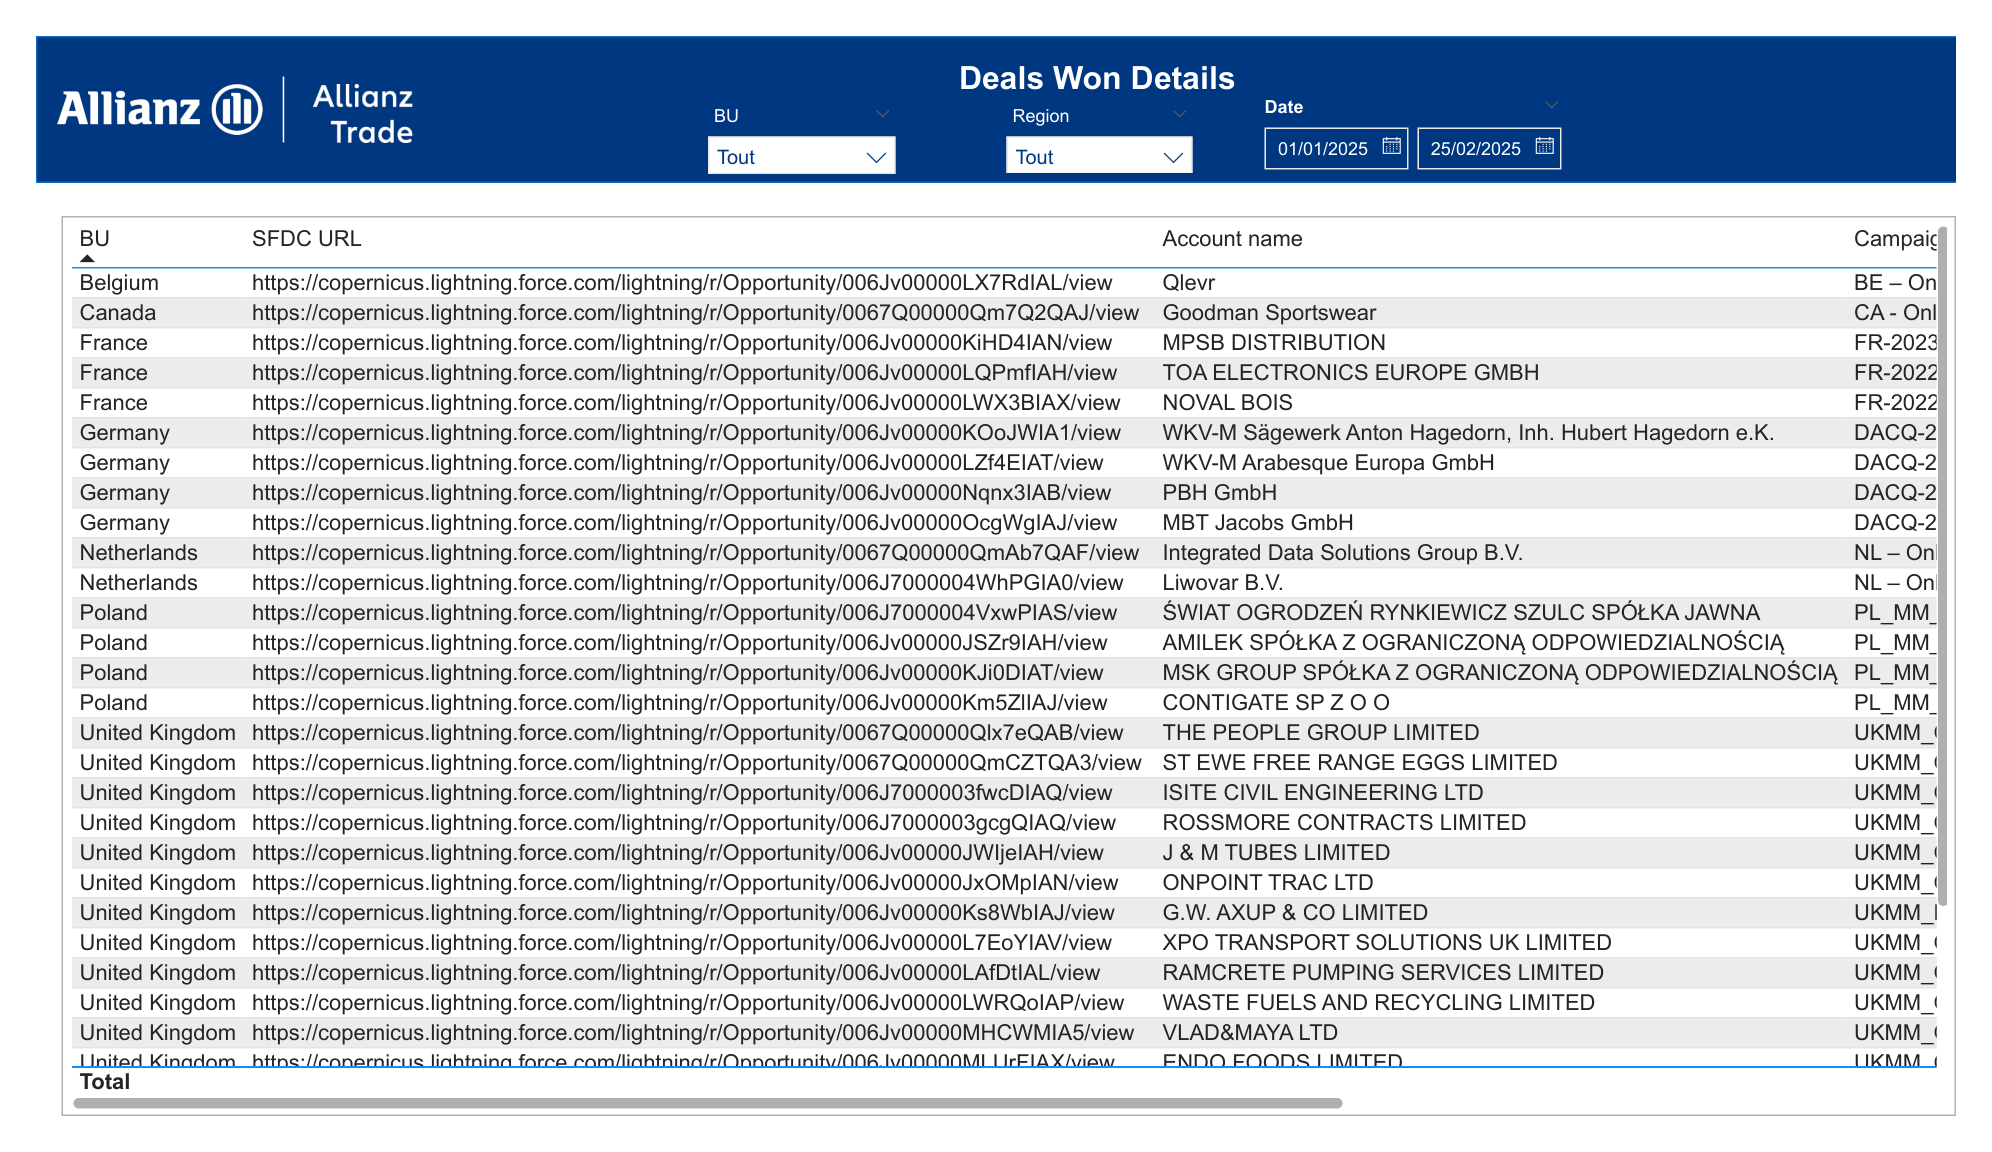
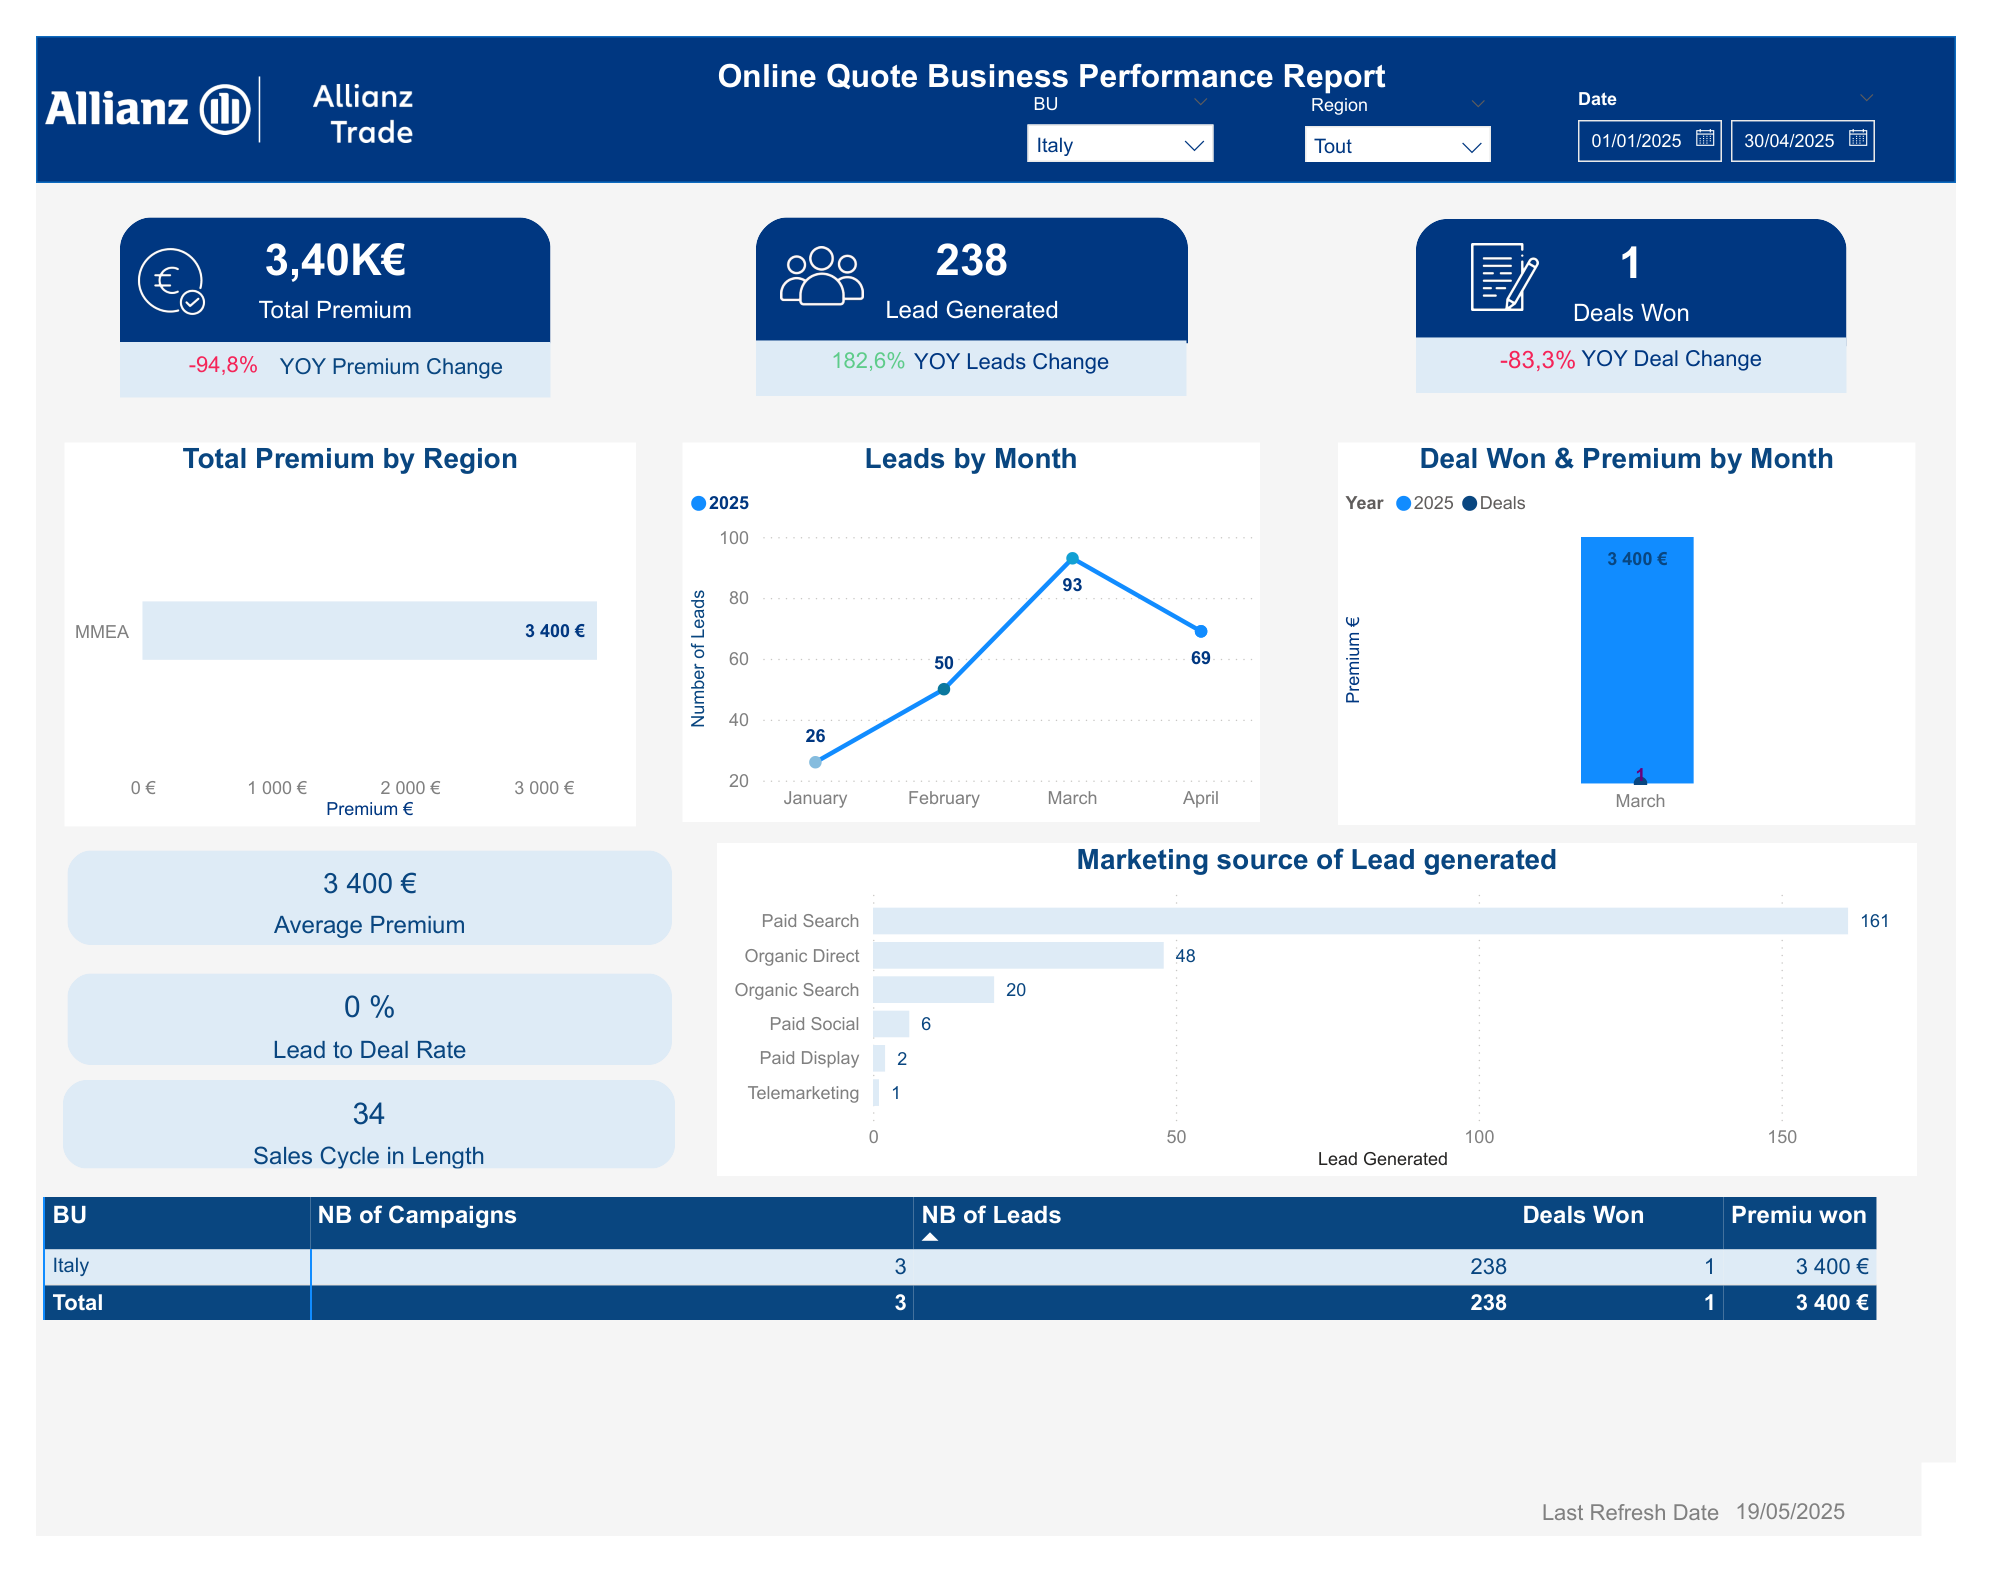
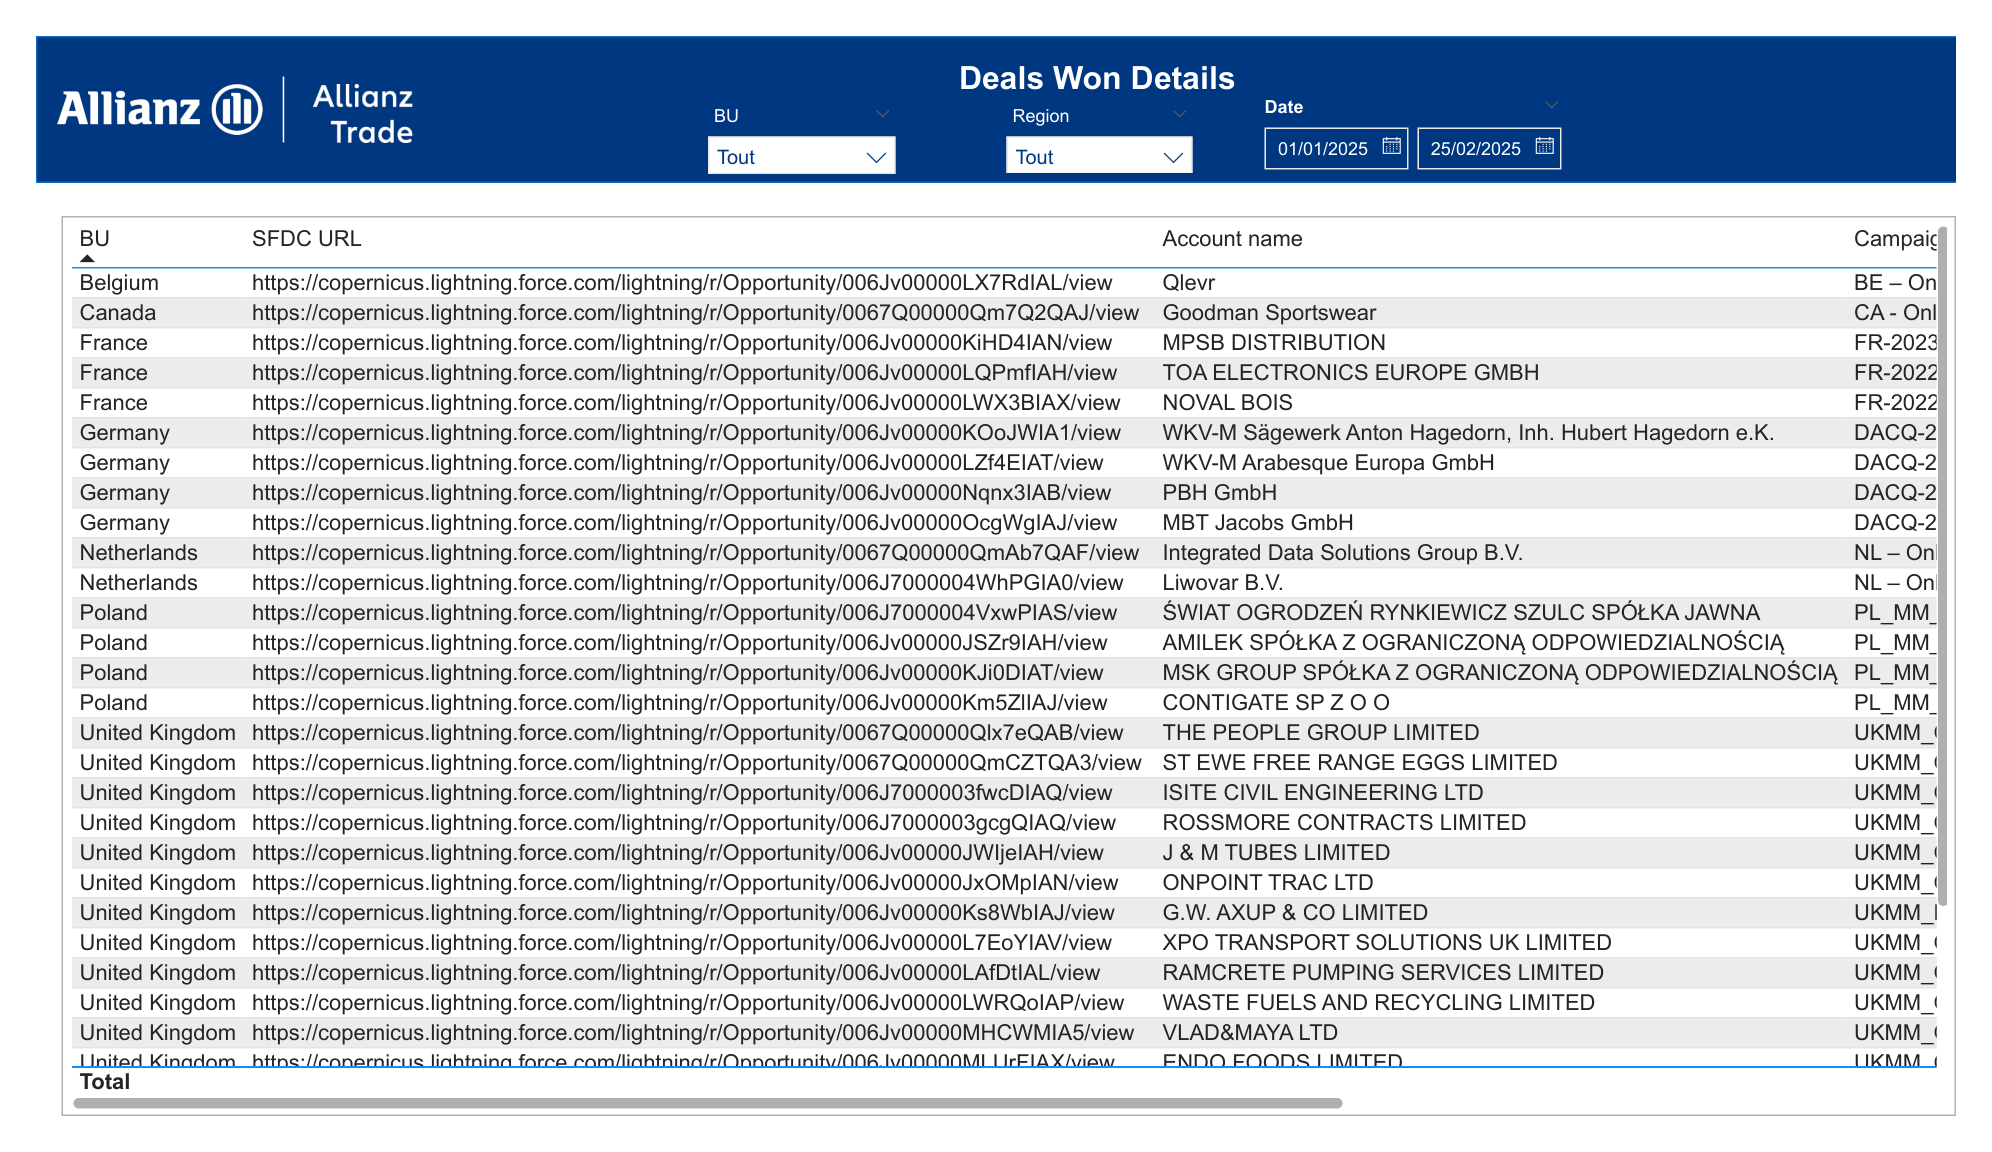
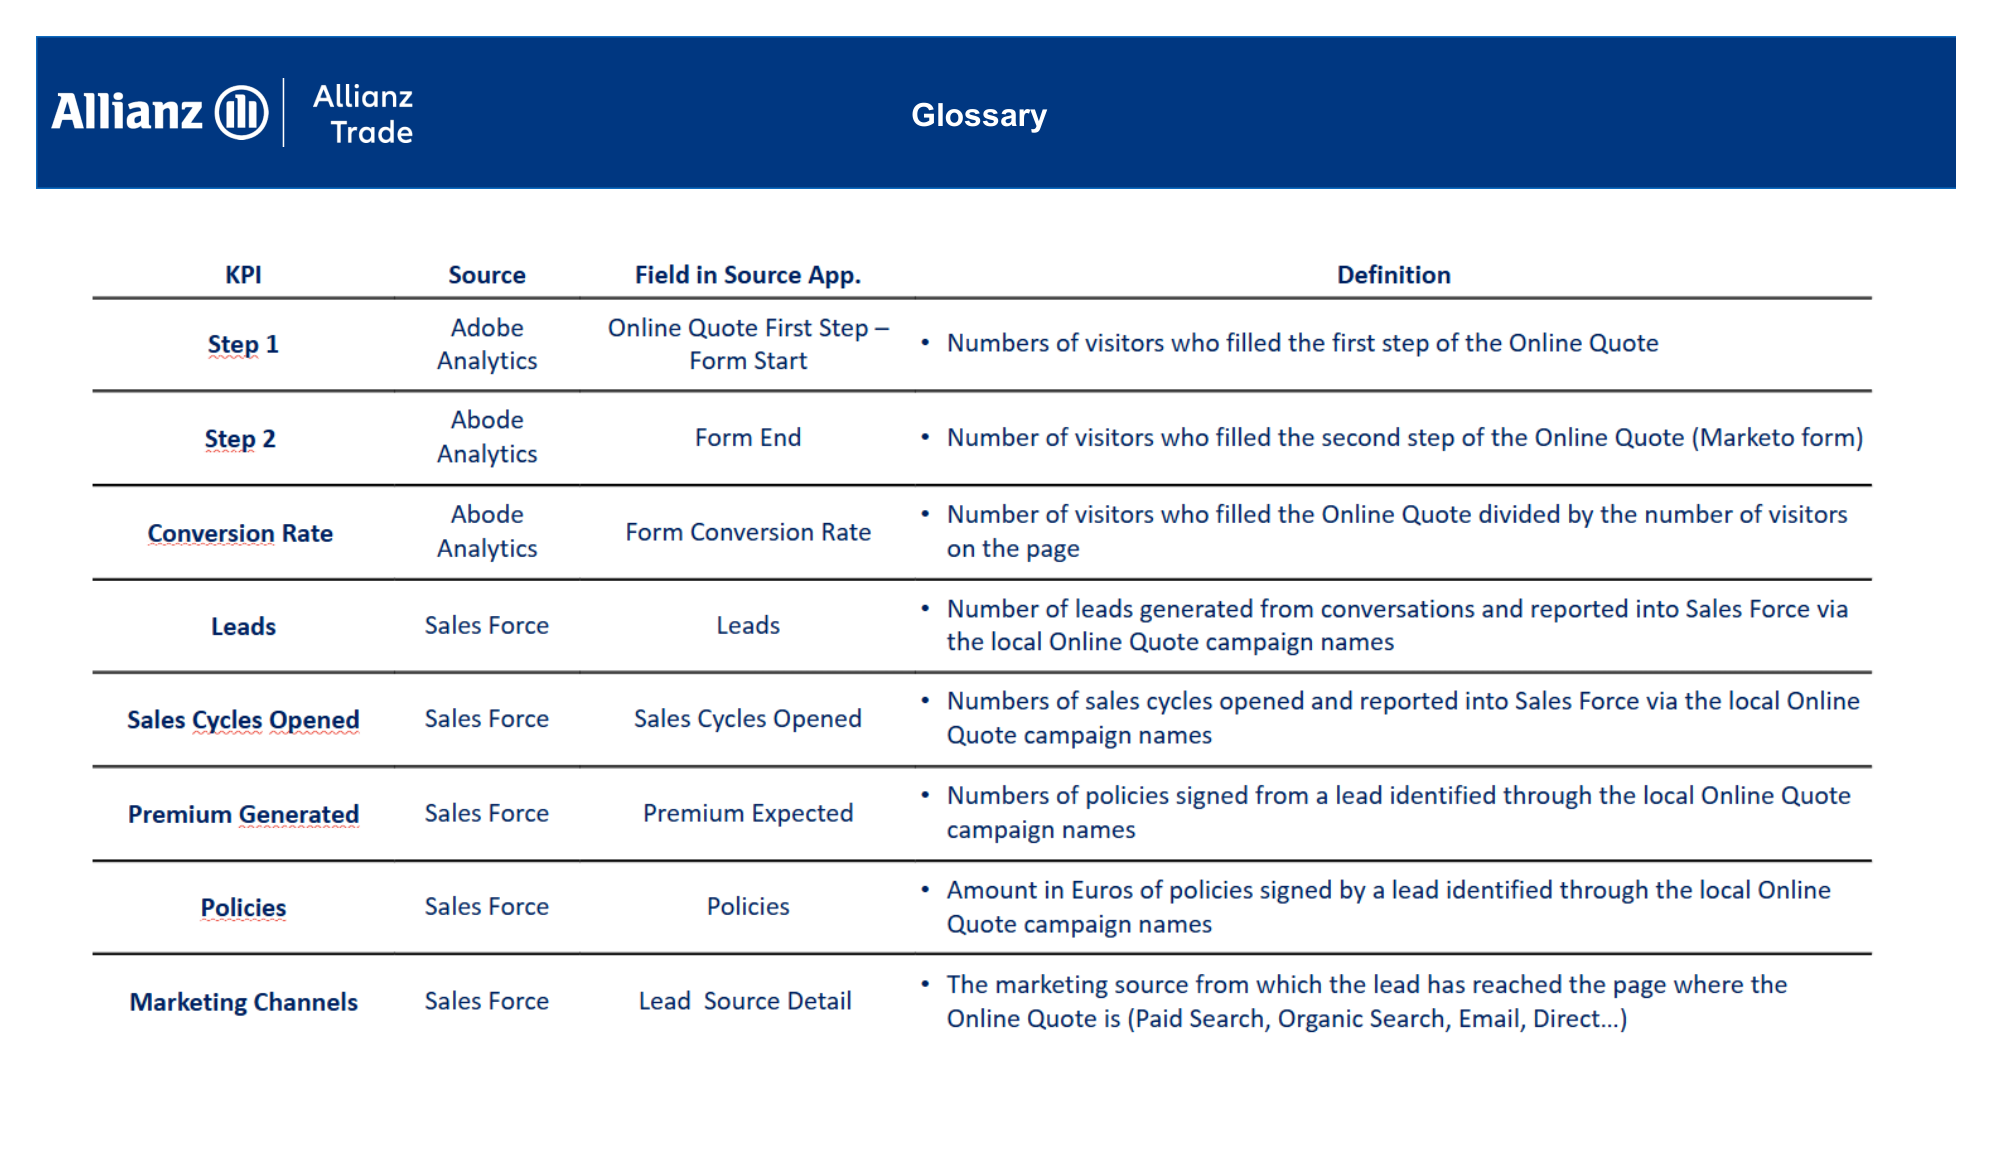

In [ ]:


# Load environment variables
load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise RuntimeError("OPENAI_API_KEY not found in environment. Please set it before running the notebook.")

OUTPUT_DIR = Path("../images")
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(exist_ok=True)

client = OpenAI(api_key=api_key)

# Collect images to send
image_files: List[str] = sorted([str(p.resolve()) for p in OUTPUT_DIR.glob("*.png")])
if not image_files:
    raise FileNotFoundError("No images found. Run the previous cell first.")

# Build content array for vision model
contents = [
    {"type": "text", "text": "i will provide you a picture and you need to write a overall purpose of the page"}
]

# Encode images as base64
for img_path in image_files:
    with open(img_path, "rb") as image_file:
        base64_image = base64.b64encode(image_file.read()).decode('utf-8')
        contents.append({
            "type": "image_url",
            "image_url": {
                "url": f"data:image/png;base64,{base64_image}"
            }
        })

        print(contents)

        

# resp = client.chat.completions.create(
#     model="gpt-4o-mini",  # lightweight vision-capable model
#     messages=[{"role": "user", "content": contents}],
#     temperature=0.0,
# )

# text = resp.choices[0].message.content

# out_path = RESULTS_DIR / "extracted_text.jsonl"
# with open(out_path, "a", encoding="utf-8") as f:
#     f.write(json.dumps({"images": image_files, "model": "gpt-4o-mini", "content": text}, ensure_ascii=False) + "\n")

# print(f"Saved model output to {out_path.resolve()}")
# print(text[:1000])
